In [1]:

# Add the parent directory to the path
from pathlib import Path
import sys
sys.path.append(str(Path().resolve().parent))

from circleplots import plot_circle
from circleplots import plot_circle_2

from circleplots import plot_circle_2_subplots


# Normal chirality

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


n = (theta, phi) = (0.0, 0.0)


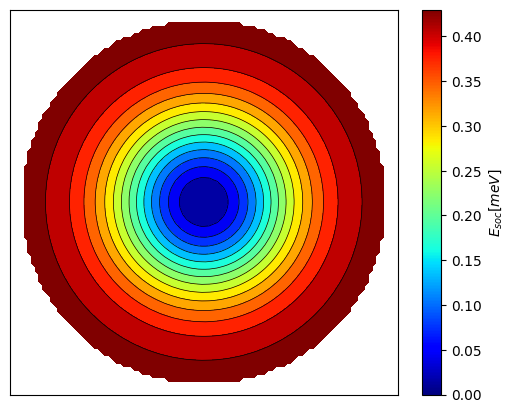

In [2]:
plot_circle('soc_data.npz',name='MnI2_circle.pdf', save=False)

# Opposite chirality

In [3]:
import numpy as np
test = np.load('soc_data_opposite_chiral.npz')

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


n = (theta, phi) = (180.0, 0.0)


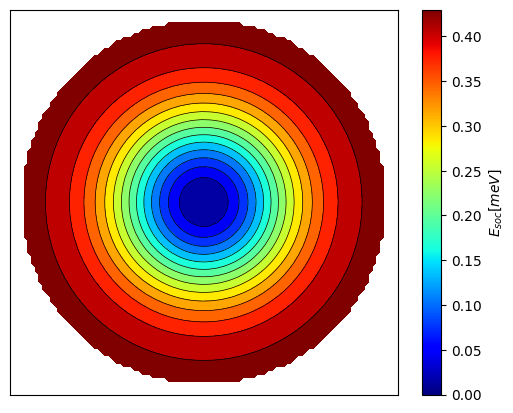

In [4]:
plot_circle('soc_data_opposite_chiral.npz',name='test_2', save=False)

# Finding difference

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Absolute SOC energies in soc_data.npz:
  min = -1793.940615 eV
  max = -1793.940185 eV
  range = 0.4299 meV
Hemisphere: Upper hemisphere (spin-up / original chirality)
SOC minimum at: (theta, phi) = (0.0 deg, 0.0 deg)
SOC minimum energy (relative to reference): 0.0000 meV


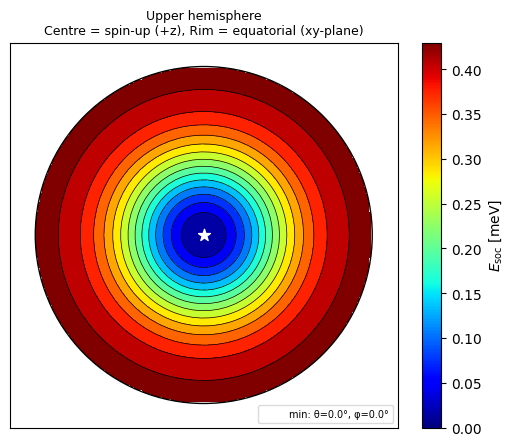

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Absolute SOC energies in soc_data_opposite_chiral.npz:
  min = -1793.940615 eV
  max = -1793.940185 eV
  range = 0.4299 meV
Hemisphere: Lower hemisphere (spin-down / opposite chirality)
SOC minimum at: (theta, phi) = (180.0 deg, 0.0 deg)
SOC minimum energy (relative to reference): 0.0000 meV


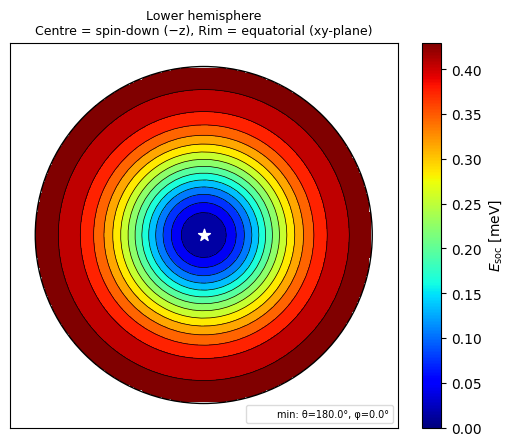

In [5]:
# First, load both datasets and find the global minimum
upper = np.load('soc_data.npz') #Upper hemisphere
lower = np.load('soc_data_opposite_chiral.npz') #Lower hemisphere

global_emin = min(np.min(upper['soc']), np.min(lower['soc']))
global_emax_mev = max(np.max(upper['soc']) - global_emin,
                      np.max(lower['soc']) - global_emin) * 1e3

# Now plot both with the same reference — directly comparable colour scales
fig_upper, ax_upper = plot_circle_2('soc_data.npz', name='upper_soc.png',
            global_emin=global_emin, global_emax=global_emax_mev)

fig_lower, ax_lower = plot_circle_2('soc_data_opposite_chiral.npz', name='lower_soc.png',
            global_emin=global_emin, global_emax=global_emax_mev)

In [6]:
# #uncomment when latex plot is desired
from matplotlib import rc
rc('text', usetex=True) 
rc('font', family='serif')

In [8]:
from importlib import reload

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


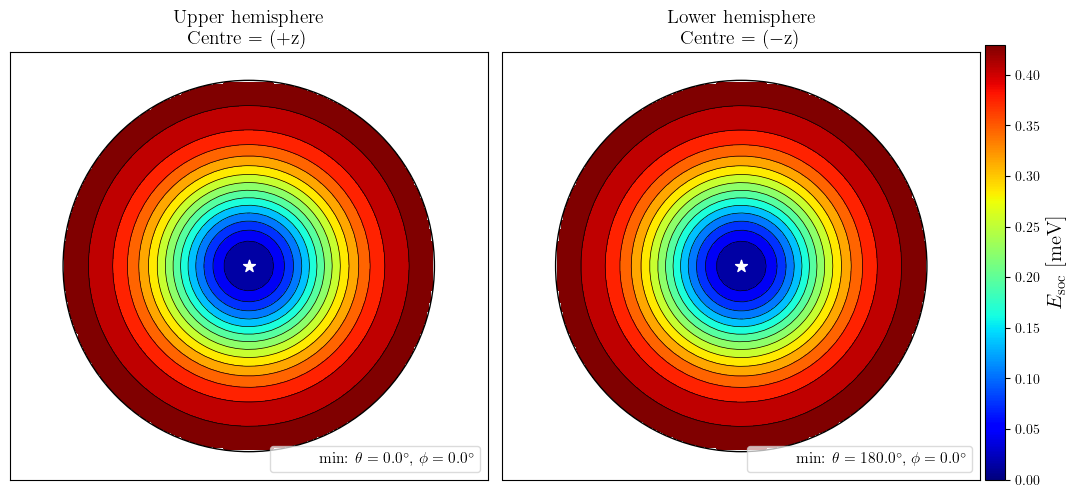

(<Figure size 1000x500 with 3 Axes>,
 (<Axes: title={'center': 'Upper hemisphere\nCentre = (+z)'}>,
  <Axes: title={'center': 'Lower hemisphere\nCentre = (−z)'}>))

In [12]:
import circleplots
reload(circleplots)

# First, load both datasets and find the global minimum
upper = np.load('soc_data.npz') #Upper hemisphere
lower = np.load('soc_data_opposite_chiral.npz') #Lower hemisphere

global_emin = min(np.min(upper['soc']), np.min(lower['soc']))
global_emax_mev = max(np.max(upper['soc']) - global_emin,
                      np.max(lower['soc']) - global_emin) * 1e3


circleplots.plot_circle_2_subplots(
    'soc_data.npz',
    'soc_data_opposite_chiral.npz',
    name='MnI2_combined_soc_plots.pdf',
    global_emin=global_emin,  # or set to a common reference
    global_emax=global_emax_mev     # or set to a common max for both
)